# Bayesian integral projection model: GP and DeepRV

This notebook applies the same IPM analysis to the separately saved GP and DeepRV MCMC posteriors. GPflow is used only to condition each sampled latent function from its observed locations onto the IPM mesh. The appropriate likelihood then converts latent moments to response-scale posterior predictive moments.

In [1]:
from pathlib import Path

import gpflow
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy import stats
from scipy.linalg import eig

gpflow.config.set_default_float(np.float64)

RANDOM_SEED = 123
N_MESH = 250
N_IPM_DRAWS = 500
BOUNDARY_MARGIN = 0.5
TRUE_LAMBDA = 1.15

DATA_PATH = Path("gp_sample250.csv")
POSTERIOR_PATHS = {
    "gp": Path("train_deeprv_v2/N_250/gp_posterior_samples.npz"),
    "deeprv": Path("train_deeprv_v2/N_250/deeprv_posterior_samples.npz"),
}

VITAL_RATES = ("survival", "reproduction", "seed", "growth")

/opt/anaconda3/envs/gpflow-env/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
REQUIRED_KEYS = (
    "survival__mu", "survival__r", "survival__ls",
    "survival__beta", "survival__s_obs",
    "reproduction__mu", "reproduction__r", "reproduction__ls",
    "reproduction__beta", "reproduction__s_obs",
    "seed__mu", "seed__r", "seed__ls",
    "seed__beta", "seed__s_obs",
    "growth__mu", "growth__r", "growth__ls",
    "growth__beta", "growth__obs_noise", "growth__s_obs",
    "recruitment__probability", "recruitment__mean",
    "recruitment__sd", "gp__jitter",
)


def load_posterior(path):
    if not path.exists():
        raise FileNotFoundError(f"Posterior not found: {path}")

    with np.load(path, allow_pickle=False) as file:
        posterior = {key: file[key] for key in file.files}

    missing = [key for key in REQUIRED_KEYS if key not in posterior]
    if missing:
        raise KeyError(f"{path} is missing arrays: {missing}")

    for rate in VITAL_RATES:
        n_values = posterior[f"{rate}__mu"].shape[1]
        n_locations = posterior[f"{rate}__s_obs"].shape[0]
        if n_values != n_locations:
            raise ValueError(
                f"{rate}: {n_values} latent values but {n_locations} locations"
            )

    return posterior


data = pd.read_csv(DATA_PATH)
posteriors = {
    method: load_posterior(path)
    for method, path in POSTERIOR_PATHS.items()
}

# Recruitment was estimated from the same data and should match across methods.
for key in (
    "recruitment__probability",
    "recruitment__mean",
    "recruitment__sd",
):
    np.testing.assert_allclose(posteriors["gp"][key], posteriors["deeprv"][key])

for method, posterior in posteriors.items():
    shapes = {rate: posterior[f"{rate}__mu"].shape for rate in VITAL_RATES}
    print(f"{method.upper()}: {shapes}")

GP: {'survival': (8000, 239), 'reproduction': (8000, 250), 'seed': (8000, 11), 'growth': (8000, 111)}
DEEPRV: {'survival': (8000, 239), 'reproduction': (8000, 250), 'seed': (8000, 11), 'growth': (8000, 111)}


In [3]:
reference_posterior = posteriors["gp"]
recruit_mean = float(np.asarray(reference_posterior["recruitment__mean"]).item())
recruit_sd = float(np.asarray(reference_posterior["recruitment__sd"]).item())

observed_sizes = [data["z"].dropna().to_numpy(dtype=np.float64)]
if "z1" in data.columns:
    observed_sizes.append(data["z1"].dropna().to_numpy(dtype=np.float64))
observed_sizes = np.concatenate(observed_sizes)

lower_bound = min(observed_sizes.min(), recruit_mean - 4.0 * recruit_sd) - BOUNDARY_MARGIN
upper_bound = max(observed_sizes.max(), recruit_mean + 4.0 * recruit_sd) + BOUNDARY_MARGIN
mesh_width = (upper_bound - lower_bound) / N_MESH
mesh = lower_bound + (np.arange(N_MESH) + 0.5) * mesh_width

print(f"Bounds: [{lower_bound:.3f}, {upper_bound:.3f}]")
print(f"Mesh points: {N_MESH}; width: {mesh_width:.5f}")

Bounds: [-3.567, 4.287]
Mesh points: 250; width: 0.03142


## Posterior prediction on the mesh

For each MCMC draw, `mu` is the sampled zero-mean latent function at `s_obs`. A temporary GPflow GPR conditions those values onto the mesh. Its Gaussian likelihood variance is fixed to the same small diagonal jitter used during inference; it is not refitted. The fitted intercept is added after conditioning, and the original vital-rate likelihood supplies response-scale predictive moments.

In [4]:
def predict_latent_moments_gpflow(
    s_obs, mu_obs, mesh, kernel_variance, kernel_lengthscale, jitter
):
    X = np.asarray(s_obs, dtype=np.float64).reshape(-1, 1)
    Y = np.asarray(mu_obs, dtype=np.float64).reshape(-1, 1)
    Xnew = np.asarray(mesh, dtype=np.float64).reshape(-1, 1)

    kernel = gpflow.kernels.SquaredExponential(
        variance=float(kernel_variance),
        lengthscales=float(kernel_lengthscale),
    )
    model = gpflow.models.GPR(
        data=(X, Y),
        kernel=kernel,
        mean_function=None,
        noise_variance=float(jitter),
    )
    latent_mean, latent_variance = model.predict_f(Xnew)
    latent_mean = latent_mean.numpy()[:, 0]
    latent_variance = np.maximum(latent_variance.numpy()[:, 0], 0.0)
    return latent_mean, latent_variance


def likelihood_predictive_moments(likelihood, mesh, latent_mean, latent_variance):
    Xnew = tf.convert_to_tensor(
        np.asarray(mesh, dtype=np.float64).reshape(-1, 1),
        dtype=gpflow.default_float(),
    )
    Fmu = tf.convert_to_tensor(
        np.asarray(latent_mean, dtype=np.float64).reshape(-1, 1),
        dtype=gpflow.default_float(),
    )
    Fvar = tf.convert_to_tensor(
        np.asarray(latent_variance, dtype=np.float64).reshape(-1, 1),
        dtype=gpflow.default_float(),
    )

    try:
        y_mean, y_variance = likelihood.predict_mean_and_var(Xnew, Fmu, Fvar)
    except TypeError:
        y_mean, y_variance = likelihood.predict_mean_and_var(Fmu, Fvar)

    return y_mean.numpy()[:, 0], y_variance.numpy()[:, 0]


def predict_vital_rate_draw(posterior, rate, draw_index, mesh):
    jitter = float(np.asarray(posterior["gp__jitter"]).item())
    latent_mean, latent_variance = predict_latent_moments_gpflow(
        s_obs=posterior[f"{rate}__s_obs"],
        mu_obs=posterior[f"{rate}__mu"][draw_index],
        mesh=mesh,
        kernel_variance=posterior[f"{rate}__r"][draw_index],
        kernel_lengthscale=posterior[f"{rate}__ls"][draw_index],
        jitter=jitter,
    )

    beta = float(posterior[f"{rate}__beta"][draw_index])
    latent_mean = latent_mean + beta

    if rate in {"survival", "reproduction"}:
        likelihood = gpflow.likelihoods.Bernoulli(invlink=tf.sigmoid)
    elif rate == "seed":
        likelihood = gpflow.likelihoods.Poisson()
    elif rate == "growth":
        obs_noise = float(posterior["growth__obs_noise"][draw_index])
        likelihood = gpflow.likelihoods.Gaussian(variance=obs_noise**2)
    else:
        raise ValueError(f"Unknown vital rate: {rate}")

    response_mean, response_variance = likelihood_predictive_moments(
        likelihood, mesh, latent_mean, latent_variance
    )
    return {
        "latent_mean": latent_mean,
        "latent_variance": latent_variance,
        "response_mean": response_mean,
        "response_variance": response_variance,
    }

In [5]:
def build_ipm_kernel(
    mesh, mesh_width, survival, reproduction, seed_mean,
    growth_mean, growth_variance, recruit_probability, recruit_mean, recruit_sd,
):
    z_next = mesh[:, None]
    growth_sd = np.sqrt(np.maximum(growth_variance, np.finfo(float).eps))
    growth_density = stats.norm.pdf(
        z_next, loc=growth_mean[None, :], scale=growth_sd[None, :]
    )
    recruit_density = stats.norm.pdf(
        z_next, loc=recruit_mean, scale=recruit_sd
    )

    P_density = (
        (1.0 - reproduction)[None, :]
        * survival[None, :]
        * growth_density
    )
    F_density = (
        reproduction[None, :]
        * seed_mean[None, :]
        * recruit_probability
        * recruit_density
    )

    P = mesh_width * P_density
    F = mesh_width * F_density
    return {
        "P": P,
        "F": F,
        "K": P + F,
        "growth_mass": mesh_width * growth_density.sum(axis=0),
    }


def normalize_positive(vector):
    vector = np.real(vector)
    if vector.sum() < 0:
        vector = -vector
    vector = np.maximum(vector, 0.0)
    if vector.sum() <= 0:
        raise ValueError("Could not normalize dominant eigenvector")
    return vector / vector.sum()


def summarize_ipm_kernel(K, P, F, mesh):
    eigenvalues, left_vectors, right_vectors = eig(K, left=True, right=True)
    dominant = np.argmax(eigenvalues.real)
    lambda_value = float(eigenvalues[dominant].real)
    stable = normalize_positive(right_vectors[:, dominant])

    reproductive_value = np.real(left_vectors[:, dominant])
    if reproductive_value @ stable < 0:
        reproductive_value = -reproductive_value
    reproductive_value = np.maximum(reproductive_value, 0.0)
    reproductive_value /= reproductive_value @ stable

    return {
        "lambda": lambda_value,
        "stable_distribution": stable,
        "reproductive_value": reproductive_value,
        "mean_stable_size": float(stable @ mesh),
        "survival_growth_contribution": float(reproductive_value @ (P @ stable)),
        "fecundity_contribution": float(reproductive_value @ (F @ stable)),
    }

In [6]:
def run_posterior_ipm(
    posterior, mesh, mesh_width, n_draws=500, random_seed=123, progress_every=50
):
    rng = np.random.default_rng(random_seed)
    n_mesh = len(mesh)

    recruit_probability = float(
        np.asarray(posterior["recruitment__probability"]).item()
    )
    recruit_mean = float(np.asarray(posterior["recruitment__mean"]).item())
    recruit_sd = float(np.asarray(posterior["recruitment__sd"]).item())

    posterior_indices = {}
    for rate in VITAL_RATES:
        available = posterior[f"{rate}__mu"].shape[0]
        if n_draws > available:
            raise ValueError(f"Requested {n_draws} draws; {rate} has {available}")
        posterior_indices[rate] = rng.choice(available, size=n_draws, replace=False)

    vital = {
        "survival": np.empty((n_draws, n_mesh)),
        "reproduction": np.empty((n_draws, n_mesh)),
        "seed": np.empty((n_draws, n_mesh)),
        "growth_mean": np.empty((n_draws, n_mesh)),
        "growth_variance": np.empty((n_draws, n_mesh)),
    }
    population = {
        "lambda": np.empty(n_draws),
        "mean_stable_size": np.empty(n_draws),
        "stable_distribution": np.empty((n_draws, n_mesh)),
        "reproductive_value": np.empty((n_draws, n_mesh)),
        "survival_growth_contribution": np.empty(n_draws),
        "fecundity_contribution": np.empty(n_draws),
    }
    growth_mass = np.empty((n_draws, n_mesh))

    for draw in range(n_draws):
        predictions = {
            rate: predict_vital_rate_draw(
                posterior, rate, posterior_indices[rate][draw], mesh
            )
            for rate in VITAL_RATES
        }
        vital["survival"][draw] = predictions["survival"]["response_mean"]
        vital["reproduction"][draw] = predictions["reproduction"]["response_mean"]
        vital["seed"][draw] = predictions["seed"]["response_mean"]
        vital["growth_mean"][draw] = predictions["growth"]["response_mean"]
        vital["growth_variance"][draw] = predictions["growth"]["response_variance"]

        ipm = build_ipm_kernel(
            mesh=mesh,
            mesh_width=mesh_width,
            survival=vital["survival"][draw],
            reproduction=vital["reproduction"][draw],
            seed_mean=vital["seed"][draw],
            growth_mean=vital["growth_mean"][draw],
            growth_variance=vital["growth_variance"][draw],
            recruit_probability=recruit_probability,
            recruit_mean=recruit_mean,
            recruit_sd=recruit_sd,
        )
        summary = summarize_ipm_kernel(ipm["K"], ipm["P"], ipm["F"], mesh)
        for key in population:
            population[key][draw] = summary[key]
        growth_mass[draw] = ipm["growth_mass"]

        if progress_every and (draw + 1) % progress_every == 0:
            print(f"Completed {draw + 1} of {n_draws} draws")

    lower = mesh[0] - 0.5 * mesh_width
    upper = mesh[-1] + 0.5 * mesh_width
    recruit_mass = stats.norm.cdf(upper, loc=recruit_mean, scale=recruit_sd) - stats.norm.cdf(
        lower, loc=recruit_mean, scale=recruit_sd
    )

    def summarize(values):
        return {
            "mean": np.mean(values),
            "median": np.median(values),
            "sd": np.std(values, ddof=1),
            "lower_95": np.quantile(values, 0.025),
            "upper_95": np.quantile(values, 0.975),
        }

    summary_table = pd.DataFrame({
        key: summarize(population[key])
        for key in (
            "lambda", "mean_stable_size",
            "survival_growth_contribution", "fecundity_contribution",
        )
    }).T

    return {
        "posterior_indices": posterior_indices,
        "vital_rates": vital,
        "population": population,
        "diagnostics": {
            "growth_mass": growth_mass,
            "recruit_mass": float(recruit_mass),
            "recruit_eviction": float(1.0 - recruit_mass),
        },
        "summary": summary_table,
    }

In [7]:
ipm_results = {}
for method, posterior in posteriors.items():
    print(f"\nRunning {method.upper()} IPM")
    ipm_results[method] = run_posterior_ipm(
        posterior=posterior,
        mesh=mesh,
        mesh_width=mesh_width,
        n_draws=N_IPM_DRAWS,
        random_seed=RANDOM_SEED,
    )

comparison_table = pd.concat(
    {method: result["summary"] for method, result in ipm_results.items()},
    names=["method", "quantity"],
)
comparison_table


Running GP IPM
Completed 50 of 500 draws
Completed 100 of 500 draws
Completed 150 of 500 draws
Completed 200 of 500 draws
Completed 250 of 500 draws
Completed 300 of 500 draws
Completed 350 of 500 draws
Completed 400 of 500 draws
Completed 450 of 500 draws
Completed 500 of 500 draws

Running DEEPRV IPM
Completed 50 of 500 draws
Completed 100 of 500 draws
Completed 150 of 500 draws
Completed 200 of 500 draws
Completed 250 of 500 draws
Completed 300 of 500 draws
Completed 350 of 500 draws
Completed 400 of 500 draws
Completed 450 of 500 draws
Completed 500 of 500 draws


mean    median        sd  lower_95  \
method quantity                                                               
gp     lambda                        1.122747  1.113779  0.112661  0.928260   
       mean_stable_size              0.545536  0.538785  0.090410  0.384540   
       survival_growth_contribution  0.804361  0.804218  0.070919  0.665917   
       fecundity_contribution        0.318386  0.305400  0.074168  0.220437   
deeprv lambda                        1.116968  1.114210  0.106860  0.923884   
       mean_stable_size              0.545801  0.540203  0.091759  0.394279   
       survival_growth_contribution  0.800499  0.801279  0.066608  0.673883   
       fecundity_contribution        0.316469  0.306448  0.072204  0.221704   

                                     upper_95  
method quantity                                
gp     lambda                        1.348912  
       mean_stable_size              0.725965  
       survival_growth_contribution  0.940798  
       fecundity_contribution        0.498164  
deeprv lambda                        1.327884  
       mean_stable_size              0.738884  
       survival_growth_contribution  0.922283  
       fecundity_contribution        0.471472

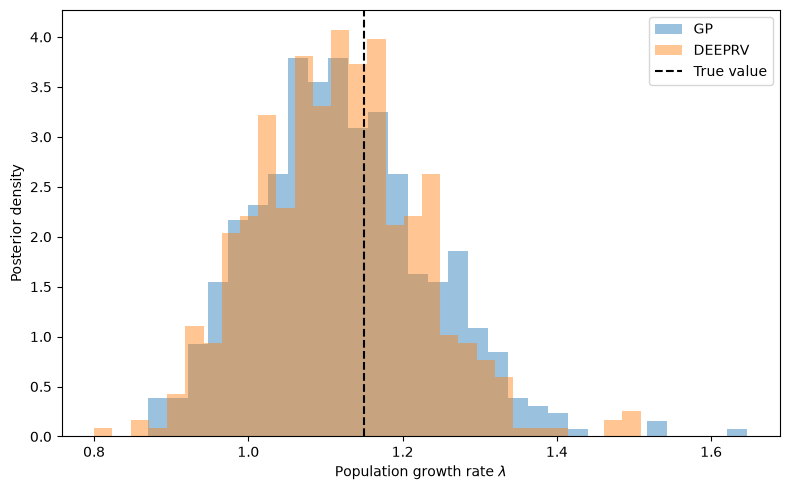

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"gp": "tab:blue", "deeprv": "tab:orange"}
for method, result in ipm_results.items():
    ax.hist(
        result["population"]["lambda"],
        bins=30,
        density=True,
        alpha=0.45,
        color=colors[method],
        label=method.upper(),
    )
ax.axvline(TRUE_LAMBDA, color="black", linestyle="--", label="True value")
ax.set_xlabel(r"Population growth rate $\lambda$")
ax.set_ylabel("Posterior density")
ax.legend()
plt.tight_layout()
plt.show()

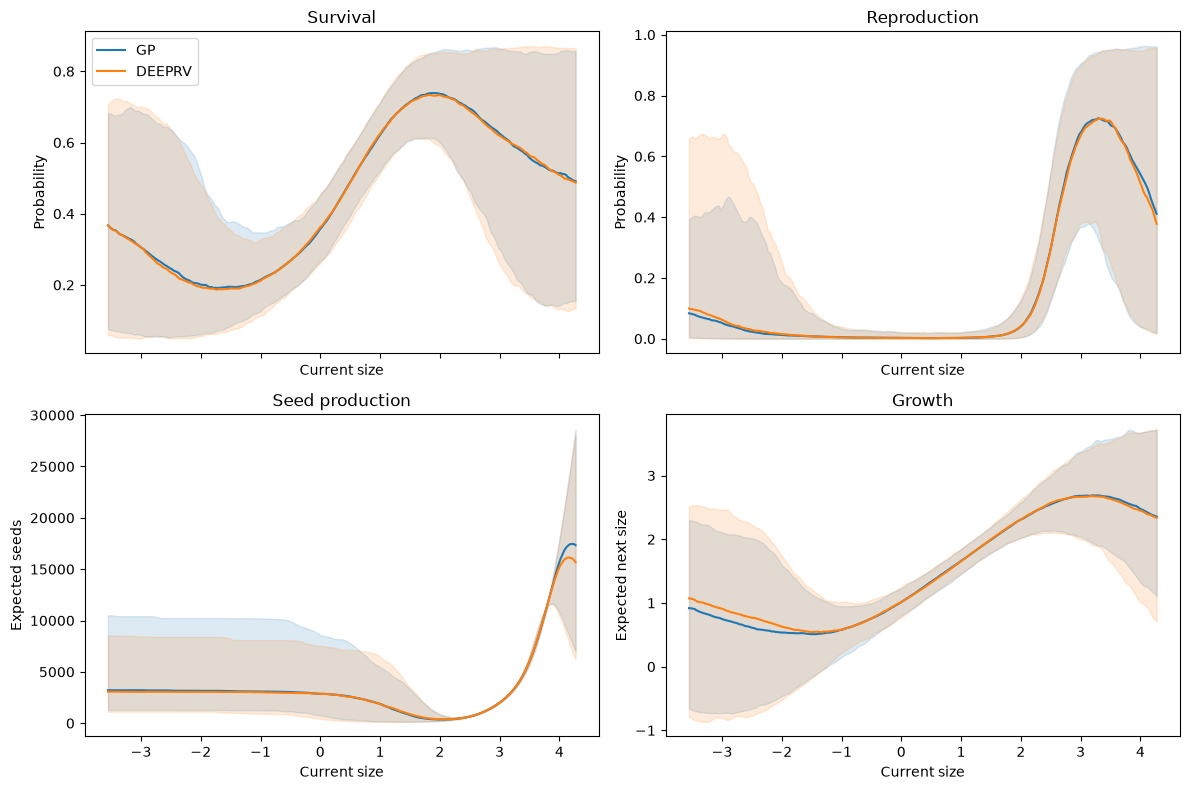

In [9]:
plot_specs = (
    ("survival", "Survival", "Probability"),
    ("reproduction", "Reproduction", "Probability"),
    ("seed", "Seed production", "Expected seeds"),
    ("growth_mean", "Growth", "Expected next size"),
)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (key, title, ylabel) in zip(axes.ravel(), plot_specs):
    for method, result in ipm_results.items():
        draws = result["vital_rates"][key]
        median = np.median(draws, axis=0)
        lower = np.quantile(draws, 0.025, axis=0)
        upper = np.quantile(draws, 0.975, axis=0)
        ax.plot(mesh, median, color=colors[method], label=method.upper())
        ax.fill_between(mesh, lower, upper, color=colors[method], alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("Current size")
    ax.set_ylabel(ylabel)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

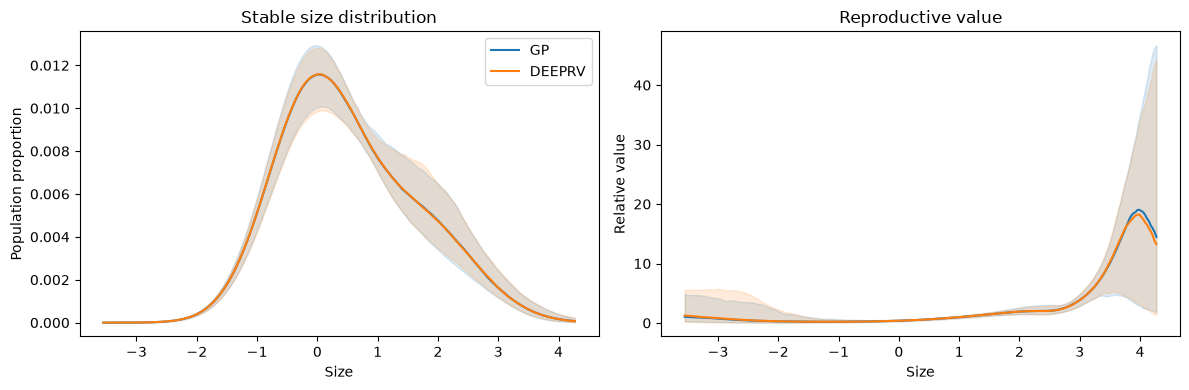

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for method, result in ipm_results.items():
    stable = result["population"]["stable_distribution"]
    rv = result["population"]["reproductive_value"]
    for ax, draws, title in (
        (axes[0], stable, "Stable size distribution"),
        (axes[1], rv, "Reproductive value"),
    ):
        median = np.median(draws, axis=0)
        lower = np.quantile(draws, 0.025, axis=0)
        upper = np.quantile(draws, 0.975, axis=0)
        ax.plot(mesh, median, color=colors[method], label=method.upper())
        ax.fill_between(mesh, lower, upper, color=colors[method], alpha=0.15)
        ax.set_title(title)
        ax.set_xlabel("Size")
axes[0].set_ylabel("Population proportion")
axes[1].set_ylabel("Relative value")
axes[0].legend()
plt.tight_layout()
plt.show()

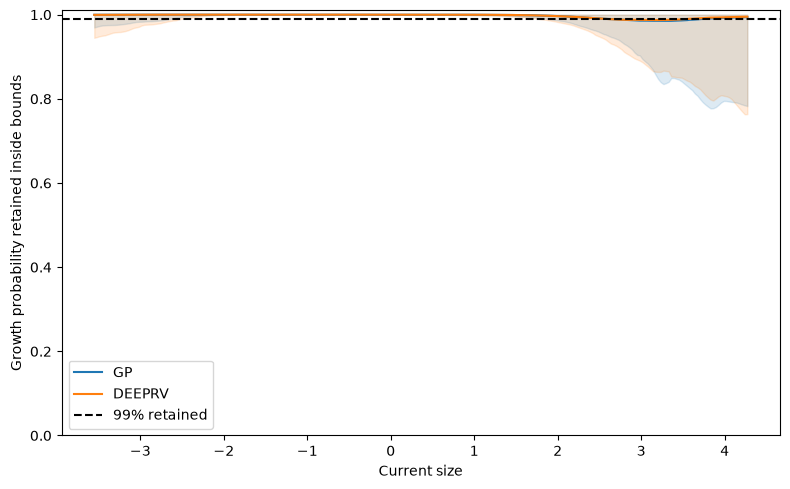

,recruit_mass_retained,recruit_eviction,median_worst_growth_mass,lower_2.5pct_worst_growth_mass
method,,,,
gp,0.999999,0.000001,0.981049,0.720044
deeprv,0.999999,0.000001,0.981549,0.707637


In [11]:
diagnostic_rows = []
fig, ax = plt.subplots(figsize=(8, 5))
for method, result in ipm_results.items():
    growth_mass = result["diagnostics"]["growth_mass"]
    median_curve = np.median(growth_mass, axis=0)
    lower_curve = np.quantile(growth_mass, 0.025, axis=0)
    ax.plot(mesh, median_curve, color=colors[method], label=method.upper())
    ax.fill_between(mesh, lower_curve, 1.0, color=colors[method], alpha=0.15)

    worst_by_draw = growth_mass.min(axis=1)
    diagnostic_rows.append({
        "method": method,
        "recruit_mass_retained": result["diagnostics"]["recruit_mass"],
        "recruit_eviction": result["diagnostics"]["recruit_eviction"],
        "median_worst_growth_mass": np.median(worst_by_draw),
        "lower_2.5pct_worst_growth_mass": np.quantile(worst_by_draw, 0.025),
    })

ax.axhline(0.99, color="black", linestyle="--", label="99% retained")
ax.set_xlabel("Current size")
ax.set_ylabel("Growth probability retained inside bounds")
ax.set_ylim(0.0, 1.01)
ax.legend()
plt.tight_layout()
plt.show()

diagnostic_table = pd.DataFrame(diagnostic_rows).set_index("method")
diagnostic_table